In [31]:
import os
import kagglehub
import librosa
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

## Гиперпараметры

In [33]:
sample_rate = 22050
duration = 30
slice_duration = 3
samples_per_slice = int(sample_rate * slice_duration)
img_height = 128
img_width = 130
num_classes = 10
batch_size = 32
epochs = 70

print("TensorFlow version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU Available: True


## Загрузка датасета

In [34]:
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
print("Path to dataset files:", path)

dataset_path = os.path.join(path, "Data", "genres_original")

Path to dataset files: /kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification



### Загрузка и нарезка аудио

In [35]:
def load_and_slice_data(dataset_path):
    features = []
    labels = []

    genres = os.listdir(dataset_path)
    for genre in genres:
        genre_path = os.path.join(dataset_path, genre)
        if not os.path.isdir(genre_path):
            continue

        print(f"Processing {genre}...")
        for filename in os.listdir(genre_path):
            file_path = os.path.join(genre_path, filename)
            try:
                signal, sr = librosa.load(file_path, sr=sample_rate, duration=duration)
                num_slices = int(len(signal) / samples_per_slice)

                for s in range(num_slices):
                    start_sample = s * samples_per_slice
                    end_sample = start_sample + samples_per_slice
                    slice_signal = signal[start_sample:end_sample]

                    mel_spec = librosa.feature.melspectrogram(
                        y=slice_signal, sr=sr, n_mels=img_height
                    )
                    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

                    if mel_spec_db.shape[1] != img_width:
                        mel_spec_db = librosa.util.fix_length(mel_spec_db, size=img_width, axis=1)

                    features.append(mel_spec_db)
                    labels.append(genre)

            except Exception as e:
                print(f"Error processing {filename}: {e}")

    return np.array(features), np.array(labels)

### Вызов загрузки и нормализация

In [36]:
x_data, y_data = load_and_slice_data(dataset_path)

x_data = x_data[..., np.newaxis]
x_data = (x_data + 40) / 40

print(f"Data shape: {x_data.shape}")

Processing disco...
Processing metal...
Processing reggae...
Processing blues...
Processing rock...
Processing classical...
Processing jazz...


/tmp/ipykernel_55/1164525868.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=sample_rate, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error processing jazz.00054.wav: 
Processing hiphop...
Processing country...
Processing pop...
Data shape: (9981, 128, 130, 1)


### Кодирование меток и разделение данных

In [37]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_data)
y_categorical = keras.utils.to_categorical(y_encoded, num_classes)

x_train, x_val, y_train, y_val = train_test_split(
    x_data, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train shape:", x_train.shape)
print("Val shape:", x_val.shape)

Train shape: (7984, 128, 130, 1)
Val shape: (1997, 128, 130, 1)


### SpecAugment

In [38]:
@tf.function
def spec_augment(feature, label):
    f = tf.random.uniform([], minval=0, maxval=20, dtype=tf.int32)
    f0 = tf.random.uniform([], minval=0, maxval=img_height - f, dtype=tf.int32)

    mask_f = tf.concat([
        tf.ones([f0, img_width, 1]),
        tf.zeros([f, img_width, 1]),
        tf.ones([img_height - f0 - f, img_width, 1])
    ], axis=0)

    t = tf.random.uniform([], minval=0, maxval=20, dtype=tf.int32)
    t0 = tf.random.uniform([], minval=0, maxval=img_width - t, dtype=tf.int32)

    mask_t = tf.concat([
        tf.ones([img_height, t0, 1]),
        tf.zeros([img_height, t, 1]),
        tf.ones([img_height, img_width - t0 - t, 1])
    ], axis=1)

    augmented_feature = feature * mask_f * mask_t
    return augmented_feature, label

### Создание data pipelines

In [39]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(len(x_train))
train_ds = train_ds.map(spec_augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(batch_size)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(batch_size)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)



### Модель: CNN + RNN (без Attention)

In [ ]:
def build_model_cnn_rnn(input_shape, n_classes):
    l2_reg = 0.001
    inputs = layers.Input(shape=input_shape)

    # CNN Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # CNN Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # CNN Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Reshape for RNN
    x = layers.Permute((2, 1, 3))(x)
    s = x.shape
    x = layers.Reshape((s[1], s[2] * s[3]))(x)

    x = layers.Dense(64, activation='swish')(x)

    # RNN Block 
    x = layers.Bidirectional(layers.GRU(64, return_sequences=False))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Classification Head
    x = layers.Dense(64, activation='swish',
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

### Модель: CNN only

In [41]:
def build_model_cnn_only(input_shape, n_classes):
    l2_reg = 0.001
    inputs = layers.Input(shape=input_shape)

    # CNN Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # CNN Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # CNN Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Classification Head (без RNN и Attention)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='swish',
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

### Модель: CNN + RNN + Attention

In [42]:
def build_model_cnn_rnn_attention(input_shape, n_classes):
    l2_reg = 0.001
    inputs = layers.Input(shape=input_shape)

    # CNN Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # CNN Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # CNN Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Reshape for RNN
    x = layers.Permute((2, 1, 3))(x)
    s = x.shape
    x = layers.Reshape((s[1], s[2] * s[3]))(x)

    x = layers.Dense(64, activation='swish')(x)

    # RNN Block
    x = layers.Bidirectional(layers.GRU(64, return_sequences=True))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Attention Block
    attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.Add()([x, attention])
    x = layers.LayerNormalization()(x)

    # Classification Head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='swish',
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

### Визуализация и оценка

In [44]:
def plot_and_evaluate(model, history, val_ds, y_val, label_encoder):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Loss')
    plt.legend()

    model.evaluate(val_ds)

    y_pred_probs = model.predict(val_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_val, axis=1)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=45)

    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

## Pipeline 1: CNN + RNN (no Attention)

In [45]:
model_cnn_rnn = build_model_cnn_rnn((img_height, img_width, 1), num_classes)
model_cnn_rnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_1 (Permute)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 16, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16, 64)         │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 284,042 (1.08 MB)

 Trainable params: 283,338 (1.08 MB)

 Non-trainable params: 704 (2.75 KB)

In [47]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model_cnn_rnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_cnn_rnn = model_cnn_rnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.3735 - loss: 2.1406 - val_accuracy: 0.6009 - val_loss: 1.6129 - learning_rate: 0.0010
Epoch 2/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.5751 - loss: 1.6816 - val_accuracy: 0.6069 - val_loss: 1.5811 - learning_rate: 0.0010
Epoch 3/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6698 - loss: 1.4840 - val_accuracy: 0.6940 - val_loss: 1.3874 - learning_rate: 0.0010
Epoch 4/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.7343 - loss: 1.3383 - val_accuracy: 0.7381 - val_loss: 1.2610 - learning_rate: 0.0010
Epoch 5/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.7809 - loss: 1.2459 - val_accuracy: 0.7977 - val_loss: 1.1623 - learning_rate: 0.0010
Epoch 6/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.8150 - loss: 1.1522 - val_accuracy: 0.8563 - val_loss: 1.0219 - learning_rate: 0.0010
Epoch 7/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.8485 - l

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9709 - loss: 0.6580
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

       blues       0.99      0.98      0.99       200
   classical       0.97      0.99      0.98       200
     country       0.97      0.96      0.97       199
       disco       0.98      0.98      0.98       200
      hiphop       0.98      0.98      0.98       200
        jazz       0.98      0.98      0.98       198
       metal       0.98      0.95      0.97       200
         pop       0.97      0.96      0.97       200
      reggae       0.98      0.98      0.98       200
        rock       0.91      0.92      0.92       200

    accuracy                           0.97      1997
   macro avg       0.97      0.97      0.97      1997
weighted avg       0.97      0.97      0.97      1997



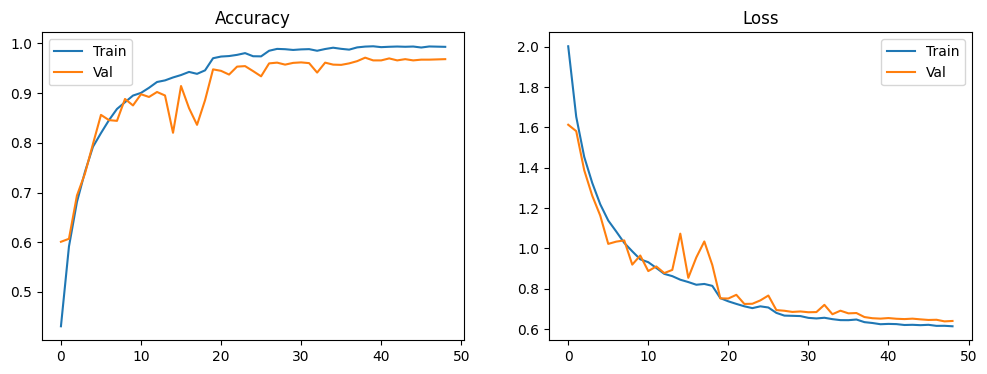

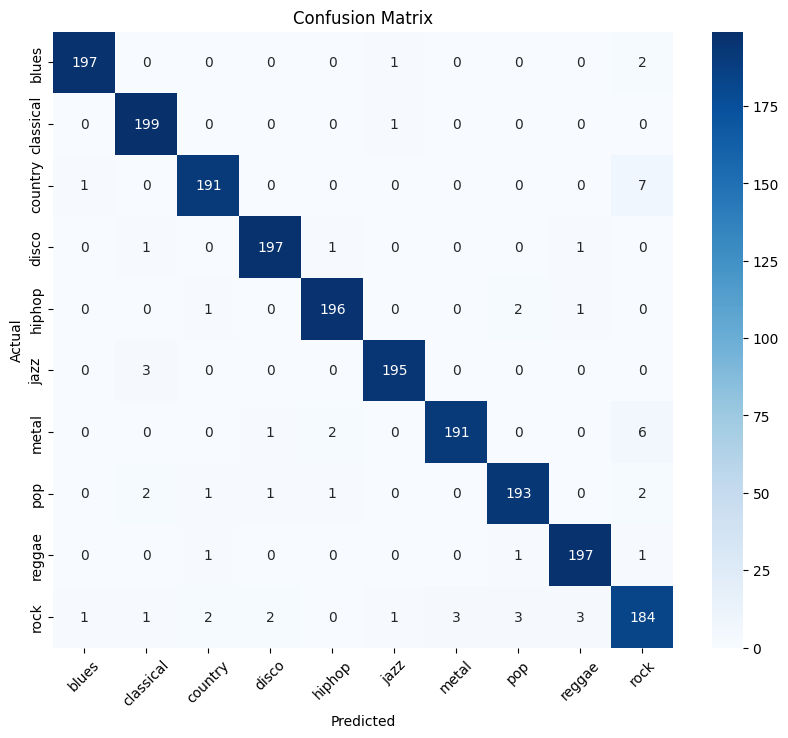

In [48]:
plot_and_evaluate(model_cnn_rnn, history_cnn_rnn, val_ds, y_val, label_encoder)

## Pipeline 2: CNN only

In [49]:
model_cnn_only = build_model_cnn_only((img_height, img_width, 1), num_classes)
model_cnn_only.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,474 (400.29 KB)

 Trainable params: 102,026 (398.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [50]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model_cnn_only.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_cnn_only = model_cnn_only.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/70


I0000 00:00:1770847732.358847     141 service.cc:152] XLA service 0x7d60087b77c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770847732.358931     141 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 13/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1395 - loss: 2.7819

I0000 00:00:1770847737.303742     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.3384 - loss: 2.1733 - val_accuracy: 0.2233 - val_loss: 2.8555 - learning_rate: 0.0010
Epoch 2/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5451 - loss: 1.7427 - val_accuracy: 0.2814 - val_loss: 3.0143 - learning_rate: 0.0010
Epoch 3/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6347 - loss: 1.5502 - val_accuracy: 0.4867 - val_loss: 1.9224 - learning_rate: 0.0010
Epoch 4/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6740 - loss: 1.4503 - val_accuracy: 0.3711 - val_loss: 2.6678 - learning_rate: 0.0010
Epoch 5/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7252 - loss: 1.3678 - val_accuracy: 0.3706 - val_loss: 2.5243 - learning_rate: 0.0010
Epoch 6/70
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7314 - loss: 1.3231
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7315 - loss: 1.3230 - val_

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9373 - loss: 0.8606
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
              precision    recall  f1-score   support

       blues       0.98      0.97      0.98       200
   classical       0.96      0.98      0.97       200
     country       0.93      0.91      0.92       199
       disco       0.96      0.96      0.96       200
      hiphop       0.95      0.94      0.95       200
        jazz       0.96      0.97      0.96       198
       metal       0.92      0.95      0.93       200
         pop       0.90      0.91      0.90       200
      reggae       0.97      0.92      0.94       200
        rock       0.87      0.87      0.87       200

    accuracy                           0.94      1997
   macro avg       0.94      0.94      0.94      1997
weighted avg       0.94      0.94      0.94      1997



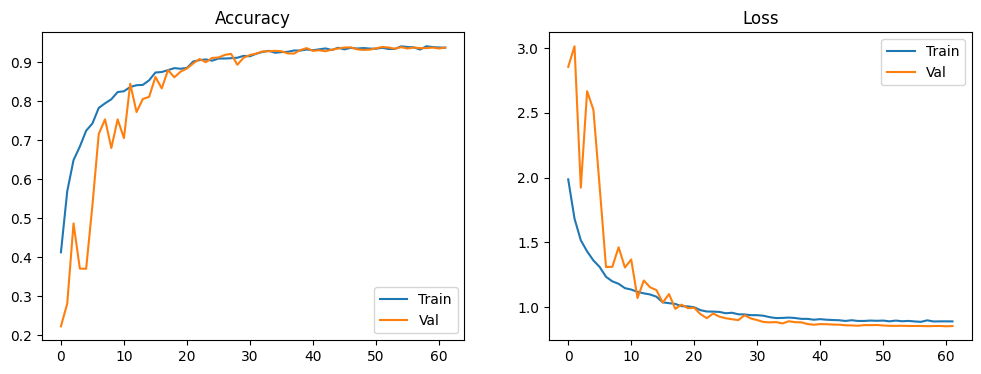

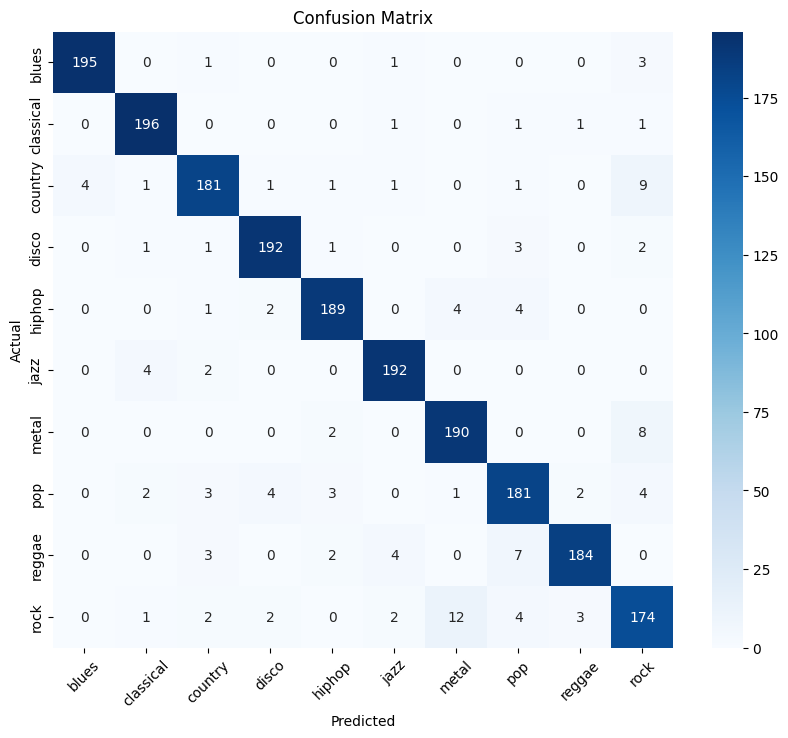

In [51]:
plot_and_evaluate(model_cnn_only, history_cnn_only, val_ds, y_val, label_encoder)

## Pipeline 3: CNN + RNN + Attention

In [57]:
model_cnn_rnn_att = build_model_cnn_rnn_attention((img_height, img_width, 1), num_classes)
model_cnn_rnn_att.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 130,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 130,  │        320 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 130,  │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 64, 65,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 65,    │     18,496 │ max_pooling2d_15… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 65,    │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 32, 32,    │          0 │ max_pooling2d_16… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │     73,856 │ dropout_21[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 16, 16,    │          0 │ max_pooling2d_17… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_4 (Permute) │ (None, 16, 16,    │          0 │ dropout_22[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 16, 2048)  │          0 │ permute_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 16, 64)    │    131,136 │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 16, 128)   │     49,920 │ dense_14[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128)   │        512 │ bidirectional_4[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 416,266 (1.59 MB)

 Trainable params: 415,562 (1.59 MB)

 Non-trainable params: 704 (2.75 KB)

In [58]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model_cnn_rnn_att.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_cnn_rnn_att = model_cnn_rnn_att.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/70


E0000 00:00:1770848541.968580      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/dropout_21_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.4255 - loss: 1.9997 - val_accuracy: 0.1002 - val_loss: 3.6026 - learning_rate: 0.0010
Epoch 2/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.6634 - loss: 1.4926 - val_accuracy: 0.2624 - val_loss: 2.7862 - learning_rate: 0.0010
Epoch 3/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.7667 - loss: 1.2806 - val_accuracy: 0.7812 - val_loss: 1.1974 - learning_rate: 0.0010
Epoch 4/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.8059 - loss: 1.1680 - val_accuracy: 0.7952 - val_loss: 1.1519 - learning_rate: 0.0010
Epoch 5/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.8420 - loss: 1.0852 - val_accuracy: 0.7997 - val_loss: 1.1700 - learning_rate: 0.0010
Epoch 6/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.8726 - loss: 1.0204 - val_accuracy: 0.8628 - val_loss: 0.9794 - learning_rate: 0.0010
Epoch 7/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.8754 - loss: 1.0035

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9784 - loss: 0.6310
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
              precision    recall  f1-score   support

       blues       0.99      0.99      0.99       200
   classical       0.97      1.00      0.98       200
     country       0.94      0.99      0.97       199
       disco       0.97      0.99      0.98       200
      hiphop       0.99      0.98      0.98       200
        jazz       0.99      0.97      0.98       198
       metal       0.97      0.97      0.97       200
         pop       0.96      0.97      0.96       200
      reggae       0.98      0.98      0.98       200
        rock       0.98      0.89      0.93       200

    accuracy                           0.97      1997
   macro avg       0.97      0.97      0.97      1997
weighted avg       0.97      0.97      0.97      1997



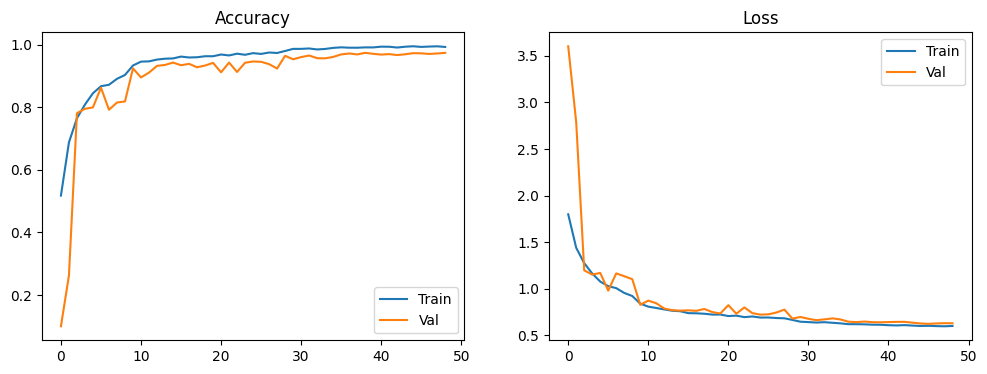

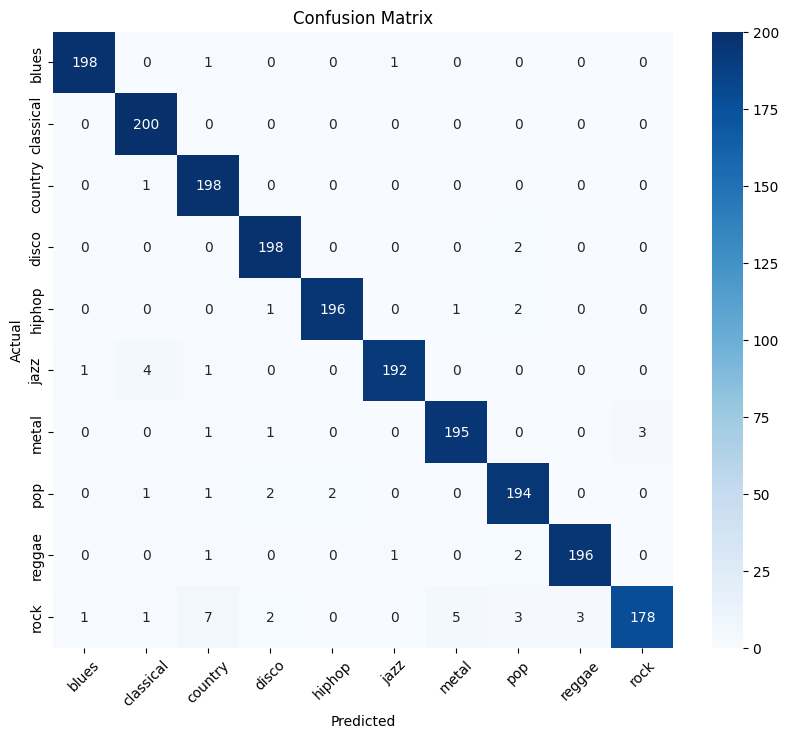

In [59]:
plot_and_evaluate(model_cnn_rnn_att, history_cnn_rnn_att, val_ds, y_val, label_encoder)